In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import plotly.express as px
# import plotly.graph_objects as go
import json
import copy
import os
from scipy import signal

In [5]:
seq = "7,2,4,3,1,2,5,6,3,1,5,6,4,4,5,2,3,2,1,3,6,4,6,3,5,1,2,4,6,5,2,5,3,4,5,1,4,1,6,2,3,6,6,1,1,5,4,5,4,3,2,2,3,4,2,6,2,1,6,5,3,1,3,3,5,5,2,6,1,6,4,1,4"
seq = seq.split(",")
seq

['7',
 '2',
 '4',
 '3',
 '1',
 '2',
 '5',
 '6',
 '3',
 '1',
 '5',
 '6',
 '4',
 '4',
 '5',
 '2',
 '3',
 '2',
 '1',
 '3',
 '6',
 '4',
 '6',
 '3',
 '5',
 '1',
 '2',
 '4',
 '6',
 '5',
 '2',
 '5',
 '3',
 '4',
 '5',
 '1',
 '4',
 '1',
 '6',
 '2',
 '3',
 '6',
 '6',
 '1',
 '1',
 '5',
 '4',
 '5',
 '4',
 '3',
 '2',
 '2',
 '3',
 '4',
 '2',
 '6',
 '2',
 '1',
 '6',
 '5',
 '3',
 '1',
 '3',
 '3',
 '5',
 '5',
 '2',
 '6',
 '1',
 '6',
 '4',
 '1',
 '4']

In [127]:
filename = r"D:\Resonance\distro-dual\msvc\mulines\src\mulines\data\whole_dataset_ES.h5"
with h5py.File(filename, 'r') as h5f:
    epochs = h5f['epochs'][:]
    raw_signal = h5f["raw_signal"][:]
    interp_signal = h5f["interp_signal"][:]
    # notch_signal = h5f['notch_filt'][:]
n_events = 34
n_samples = 2000

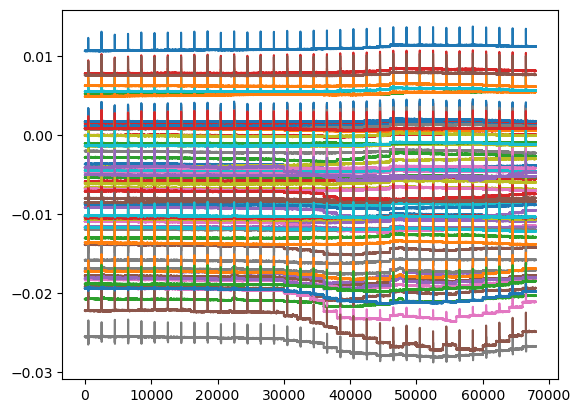

In [132]:
plt.plot(epochs);

In [128]:
filename = r"D:\Resonance\distro-dual\msvc\bin\04_ES_SMA_qp_0_bad.hdf5"
with h5py.File(filename, 'r') as h5f:
    blocks = h5f['eeg/blocks'][:]
block_signal = np.zeros(len(raw_signal))
block_signal[np.cumsum(blocks["samples"])-1] = 1

In [129]:
shift = 2000

In [130]:
raw_signal.shape, interp_signal.shape, notch_signal.shape, raw_signal.shape[0] - interp_signal.shape[0]

((5171000, 67), (5170960, 67), (5172929, 66), 40)

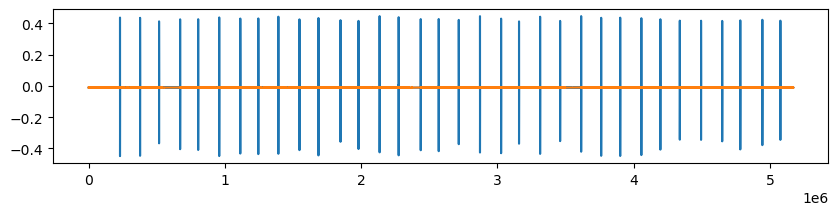

In [131]:
plt.figure(figsize=(10, 2))
plt.plot(raw_signal[:, 10])
plt.plot(interp_signal[:, 10]);

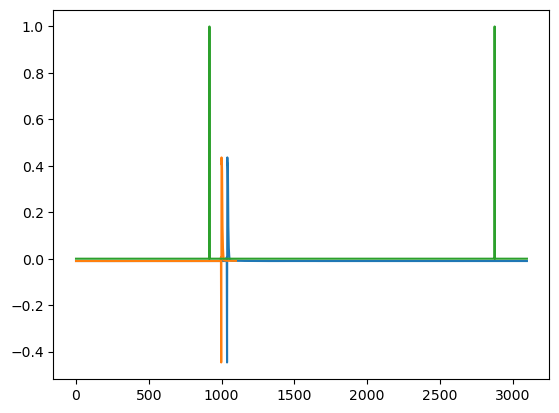

In [68]:
start_idx = np.where(interp_signal[:, 10]>0.2)[0][0]-1000
end_idx = np.where(interp_signal[:, 10]>0.2)[0][0]+100
plt.plot(raw_signal[start_idx-shift:end_idx, 10])
plt.plot(interp_signal[start_idx:end_idx, 10]);
plt.plot(block_signal[start_idx-shift:end_idx]);

In [33]:
start_idx

array([3762362, 3762363, 3762364, 3762365, 3762366, 3762367])

In [126]:
filename = r"C:\Users\Anatoly\Downloads\im1.edf"
import numpy as np
import pyedflib

# Самый простой рабочий код
f = pyedflib.EdfReader(filename)
n = f.signals_in_file
print(f"В файле {n} каналов")
data = f.readSignal(0)  # читаем первый канал
print(f"Данные первого канала: {len(data)} точек")
f.close()

OSError: C:\Users\Anatoly\Downloads\im1.edf: the file is not EDF(+) or BDF(+) compliant (Physical Maximum)

In [125]:
len(data)

8

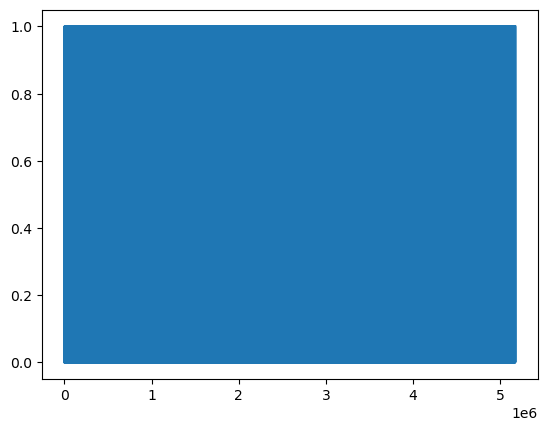

In [23]:

plt.plot(block_signal);

array([   1960,    3880,    5880, ..., 5167000, 5169000, 5171000],
      dtype=uint64)